<a href="https://colab.research.google.com/github/loki20051267/hpc-project/blob/main/paper10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using: cpu
Epoch 0 | Loss 0.7142 | Acc 0.5252
Epoch 1 | Loss 0.6928 | Acc 0.5403
Epoch 2 | Loss 0.6733 | Acc 0.5578
Epoch 3 | Loss 0.6550 | Acc 0.5775
Epoch 4 | Loss 0.6379 | Acc 0.6073
Epoch 5 | Loss 0.6215 | Acc 0.6406
Epoch 6 | Loss 0.6058 | Acc 0.6741
Epoch 7 | Loss 0.5912 | Acc 0.7035
Epoch 8 | Loss 0.5775 | Acc 0.7329
Epoch 9 | Loss 0.5646 | Acc 0.7637
Epoch 10 | Loss 0.5524 | Acc 0.8318
Epoch 11 | Loss 0.5407 | Acc 0.8529
Epoch 12 | Loss 0.5295 | Acc 0.8580
Epoch 13 | Loss 0.5186 | Acc 0.8613
Epoch 14 | Loss 0.5081 | Acc 0.8637


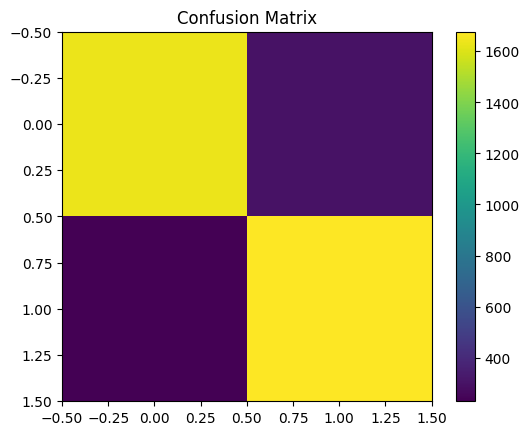

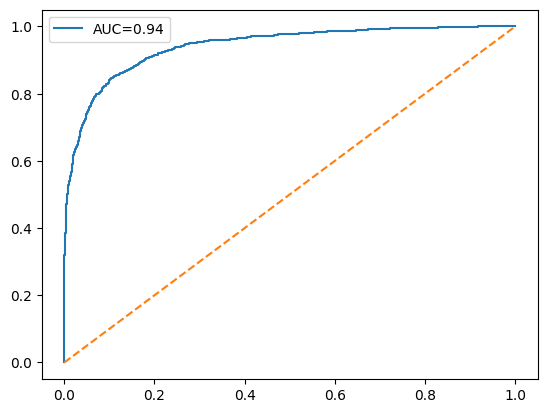

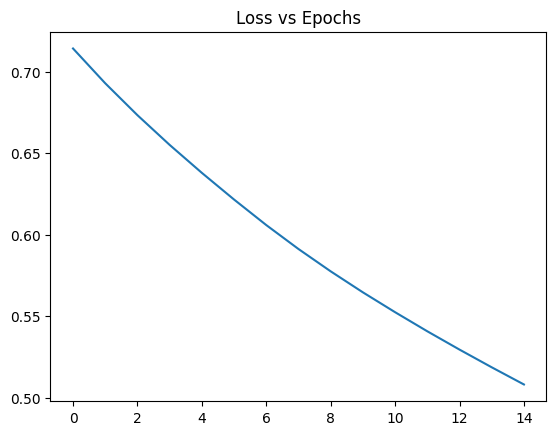

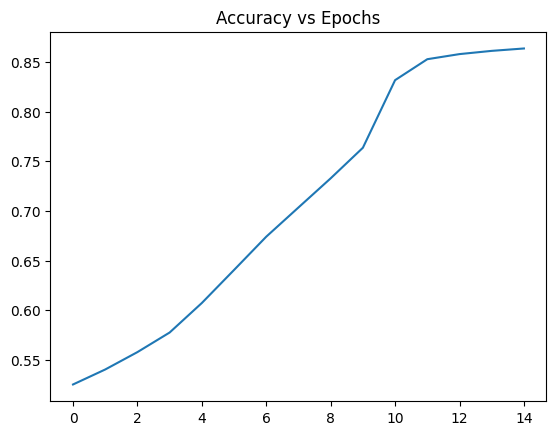

In [2]:
# ==============================
# INSTALL (run once)
# ==============================
!pip install torch torchvision torchaudio -q
!pip install torch-geometric scikit-learn -q

# ==============================
# IMPORTS
# ==============================
import torch
import torch.nn as nn
import pandas as pd
import numpy as np

from torch_geometric.nn import GCNConv
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, auc

import matplotlib.pyplot as plt

# ==============================
# DEVICE (GPU if available)
# ==============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

# ==============================
# LOAD DATA
# ==============================
file1 = "/content/S10S1.csv"
file2 = "/content/S10S2.csv"

data1 = pd.read_csv(file1)
data2 = pd.read_csv(file2)

data = pd.concat([data1, data2], axis=0)

X = data.iloc[:, :-1].values
y_raw = data.iloc[:, -1].values

# FAST label conversion
y = (y_raw > np.median(y_raw)).astype(int)

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.long)

# ==============================
# GRAPH CREATION
# ==============================
num_nodes = X.shape[1]

edges = []
for i in range(num_nodes - 1):
    edges.append([i, i + 1])
    edges.append([i + 1, i])

edge_index = torch.tensor(edges).t().contiguous().to(device)

# ==============================
# TRAIN TEST SPLIT
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

X_train, X_test = X_train.to(device), X_test.to(device)
y_train, y_test = y_train.to(device), y_test.to(device)

# ==============================
# FAST TGNN MODEL
# ==============================
class FastTGNN(nn.Module):
    def __init__(self, num_features):
        super().__init__()

        self.gcn1 = GCNConv(1, 32)
        self.gcn2 = GCNConv(32, 16)

        self.lstm = nn.LSTM(16 * num_features, 32, batch_first=True)
        self.fc = nn.Linear(32, 2)

    def forward(self, x):
        batch_size, num_features = x.shape
        x = x.unsqueeze(-1)

        outputs = []
        for i in range(batch_size):
            xi = x[i]
            xi = self.gcn1(xi, edge_index)
            xi = torch.relu(xi)
            xi = self.gcn2(xi, edge_index)
            xi = torch.relu(xi)
            outputs.append(xi.flatten())

        x = torch.stack(outputs)
        x = x.unsqueeze(1)

        x, _ = self.lstm(x)
        x = x.squeeze(1)

        return self.fc(x)

# ==============================
# MODEL INIT
# ==============================
model = FastTGNN(X.shape[1]).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# ==============================
# TRAINING
# ==============================
epochs = 15

loss_list = []
acc_list = []

for epoch in range(epochs):
    model.train()

    output = model(X_train)
    loss = criterion(output, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    _, pred = torch.max(output, 1)
    acc = (pred == y_train).float().mean().item()

    loss_list.append(loss.item())
    acc_list.append(acc)

    print(f"Epoch {epoch} | Loss {loss.item():.4f} | Acc {acc:.4f}")

# ==============================
# EVALUATION
# ==============================
model.eval()
with torch.no_grad():
    output = model(X_test)
    probs = torch.softmax(output, dim=1)[:, 1]
    _, pred = torch.max(output, 1)

# ==============================
# CONFUSION MATRIX
# ==============================
cm = confusion_matrix(y_test.cpu(), pred.cpu())

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.savefig("confusion_matrix.png", dpi=300)
plt.show()

# ==============================
# ROC CURVE
# ==============================
fpr, tpr, _ = roc_curve(y_test.cpu(), probs.cpu())
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC={roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.savefig("roc_curve.png", dpi=300)
plt.show()

# ==============================
# LOSS GRAPH
# ==============================
plt.figure()
plt.plot(loss_list)
plt.title("Loss vs Epochs")
plt.savefig("loss.png", dpi=300)
plt.show()

# ==============================
# ACCURACY GRAPH
# ==============================
plt.figure()
plt.plot(acc_list)
plt.title("Accuracy vs Epochs")
plt.savefig("accuracy.png", dpi=300)
plt.show()